# check the converge of the HL-gap wrt. to the number of conformers

In [21]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
notebook_dir = os.path.abspath('')  # current directory: /home/sat/HL-gaps-pub/notebooks
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))  # /home/sat/HL-gaps-pub
sys.path.insert(0, project_root)

In [3]:
from hl_gaps_pub.hl_gaps_pub import calculate_gap, embed_confs

In [4]:
try:
    df = pd.read_pickle("data/processed/gap_smile.pkl")
except FileNotFoundError:
    print("Error: 'data/processed/gap_smile.pkl' not found.")

Error: 'data/processed/gap_smile.pkl' not found.


In [6]:
# The functions calculate_gap and embed_confs are assumed to be imported
# from hl_gaps_pub.hl_gaps_pub as shown in your notebook.

def analyze_conformer_convergence(df, smiles_column='SMILE', num_smiles_to_sample=10, conformer_counts=[5, 10, 20, 40]):
    """
    Calculates HL-gaps for a random selection of SMILES from a DataFrame,
    varying the number of conformers.

    Args:
        df (pd.DataFrame): DataFrame containing SMILES strings.
        smiles_column (str): Name of the column in df with SMILES strings.
                             Defaults to 'SMILES'.
        num_smiles_to_sample (int): Number of random SMILES to select from df.
                                    Defaults to 10.
        conformer_counts (list): List of integers representing the number of
                                 conformers to generate for each SMILES.
                                 Defaults to [5, 10, 20, 50].

    Returns:
        list: A list of dictionaries, where each dictionary contains:
              'smiles': The SMILES string.
              'num_conformers': The number of conformers used.
              'hl_gap': The calculated HL-gap (float or None if error).
              'error': Error message if calculation failed (str or None).
    """
    results = []

    if not isinstance(df, pd.DataFrame):
        print("Error: Input 'df' is not a pandas DataFrame.")
        return results
    if smiles_column not in df.columns:
        print(f"Error: Smiles column '{smiles_column}' not found in DataFrame.")
        return results
    if df.empty:
        print("Error: Input DataFrame 'df' is empty.")
        return results

    # Ensure num_smiles_to_sample is not greater than available SMILES
    actual_smiles_to_sample = min(num_smiles_to_sample, len(df[smiles_column].unique()))
    
    if actual_smiles_to_sample == 0:
        print("No SMILES available to sample.")
        return results

    # Sample unique SMILES to avoid redundant processing if duplicates exist
    # and sampling is less than total unique SMILES.
    # If num_smiles_to_sample is larger than unique SMILES, it will take all unique ones.
    sampled_smiles = df[smiles_column].drop_duplicates().sample(
        n=actual_smiles_to_sample,
        random_state=42  # for reproducibility
    ).tolist()

    print(f"Selected {len(sampled_smiles)} SMILES for analysis: {sampled_smiles}")

    for smile_string in sampled_smiles:
        print(f"\nProcessing SMILES: {smile_string}")
        for n_confs in conformer_counts:
            print(f"  Attempting with {n_confs} conformers...")
            hl_gap_value = None
            error_message = None
            try:
                # Step 1: Embed conformers
                # embed_confs is expected to return a molecule object with conformers,
                # or None/raise an exception on failure.
                mol_with_confs = embed_confs(smile=smile_string, num_confs=n_confs)

                if mol_with_confs is None:
                    error_message = f"Conformer generation failed for {n_confs} conformers."
                    print(f"    {error_message}")
                else:
                    # Step 2: Calculate HL-gap
                    # calculate_gap is expected to take the output of embed_confs
                    hl_gap_value = calculate_gap(molecule=mol_with_confs, method='GFN2-xTB', accuracy=1.0, temperature=300.0)
                    if hl_gap_value is not None: # Assuming calculate_gap might return None on error
                        print(f"    Successfully calculated HL-gap: {hl_gap_value:.4f} eV (for {n_confs} conformers)")
                    else:
                        error_message = "HL-gap calculation returned None."
                        print(f"    {error_message}")


            except Exception as e:
                error_message = f"An error occurred: {str(e)}"
                print(f"    {error_message}")
            
            results.append({
                'smiles': smile_string,
                'num_conformers': n_confs,
                'hl_gap': hl_gap_value,
                'error': error_message
            })
            
    return results

In [ ]:
results= analyze_conformer_convergence(df)

Selected 10 SMILES for analysis: ['N(=C)C=1C=NC2=CNOC12', 'OC(C1=CC=C(C=C1)C)CC2=NC=3C=CC=CC3O2', 'O=C(Cl)C1=CC(OC)=C(OC)C(OC)=C1OC', 'O=C(OCC=CCCCCCC)C(C)CCCC(O)(C)CCCC(C)CCC(=O)C1=C(C=CCC1(C)C)C', 'O=C(C=CC1=CC=C(O)C=C1)C(O)C2(C)C(O)C(O)CC3(C)C4C(=CC(=O)C32)CC5(C)CCC6C(C)(CO)C(O)CCC6(C)C5CC4', 'OC1=CC=C(C=C1)CC2C3=CC(O)=C(OC)C=C3CCN2C', 'O=C(O)C1OC1(C)C2CCCC2C(=O)O', 'N#CC1=CC=C(C=C1)C(=O)N2CC3C4=C(C=CC(=O)N4CC(C2)C3)C=CC', 'O=C(O)C(C=1C=CC=CC1)CC2=CC(O)=C(O)C(Br)=C2Br', 'O=C(O)C(NC(=O)C=1N=C(C=2C=CC=CC2)N(N1)C3=CC=C(C=C3)C)CCSC']

Processing SMILES: N(=C)C=1C=NC2=CNOC12
  Attempting with 5 conformers...


/home/sat/HL-gaps-pub/hl_gaps_pub/hl_gaps_pub.py:360: ResourceWarning: unclosed file <_io.TextIOWrapper name='/dev/null' mode='a' encoding='utf-8'>
  optimizer = BFGS(mol_ase, trajectory=None, logfile=None)
/tmp/ipykernel_23944/3431902248.py:73: ResourceWarning: unclosed file <_io.TextIOWrapper name='/dev/null' mode='a' encoding='utf-8'>
  hl_gap_value = calculate_gap(molecule=mol_with_confs, method='GFN2-xTB', accuracy=1.0, temperature=300.0)


    Successfully calculated HL-gap: 2.1376 eV (for 5 conformers)
  Attempting with 10 conformers...
    Successfully calculated HL-gap: 2.1466 eV (for 10 conformers)
  Attempting with 20 conformers...
    Successfully calculated HL-gap: 2.1272 eV (for 20 conformers)
  Attempting with 40 conformers...
    Successfully calculated HL-gap: 2.1488 eV (for 40 conformers)

Processing SMILES: OC(C1=CC=C(C=C1)C)CC2=NC=3C=CC=CC3O2
  Attempting with 5 conformers...
    Successfully calculated HL-gap: 3.5731 eV (for 5 conformers)
  Attempting with 10 conformers...
    Successfully calculated HL-gap: 3.8191 eV (for 10 conformers)
  Attempting with 20 conformers...
    Successfully calculated HL-gap: 3.6415 eV (for 20 conformers)
  Attempting with 40 conformers...
    Successfully calculated HL-gap: 3.6847 eV (for 40 conformers)

Processing SMILES: O=C(Cl)C1=CC(OC)=C(OC)C(OC)=C1OC
  Attempting with 5 conformers...
    Successfully calculated HL-gap: 2.5556 eV (for 5 conformers)
  Attempting with 10 

## use results from batch job

In [17]:
# --- To load them back later (for verification or future use) ---
# Load from CSV
# loaded_df_csv = pd.read_csv("conformer_convergence_results.csv")
# print("\\nLoaded from CSV:")
# print(loaded_df_csv.head())

# Load from Pickle
loaded_df_pickle = pd.read_pickle("Conformer_convergence_dir/conformer_convergence_results.pkl")
print("\nLoaded from Pickle:")
loaded_df_pickle


Loaded from Pickle:


,smiles,num_conformers,hl_gap,error
0,N(=C)C=1C=NC2=CNOC12,5,2.137625,None
1,N(=C)C=1C=NC2=CNOC12,10,2.146602,None
2,N(=C)C=1C=NC2=CNOC12,20,2.127153,None
3,N(=C)C=1C=NC2=CNOC12,40,2.148844,None
4,OC(C1=CC=C(C=C1)C)CC2=NC=3C=CC=CC3O2,5,3.573087,None
5,OC(C1=CC=C(C=C1)C)CC2=NC=3C=CC=CC3O2,10,3.819050,None
6,OC(C1=CC=C(C=C1)C)CC2=NC=3C=CC=CC3O2,20,3.641523,None
7,OC(C1=CC=C(C=C1)C)CC2=NC=3C=CC=CC3O2,40,3.684679,None
8,O=C(Cl)C1=CC(OC)=C(OC)C(OC)=C1OC,5,2.555568,None
9,O=C(Cl)C1=CC(OC)=C(OC)C(OC)=C1OC,10,2.549701,None


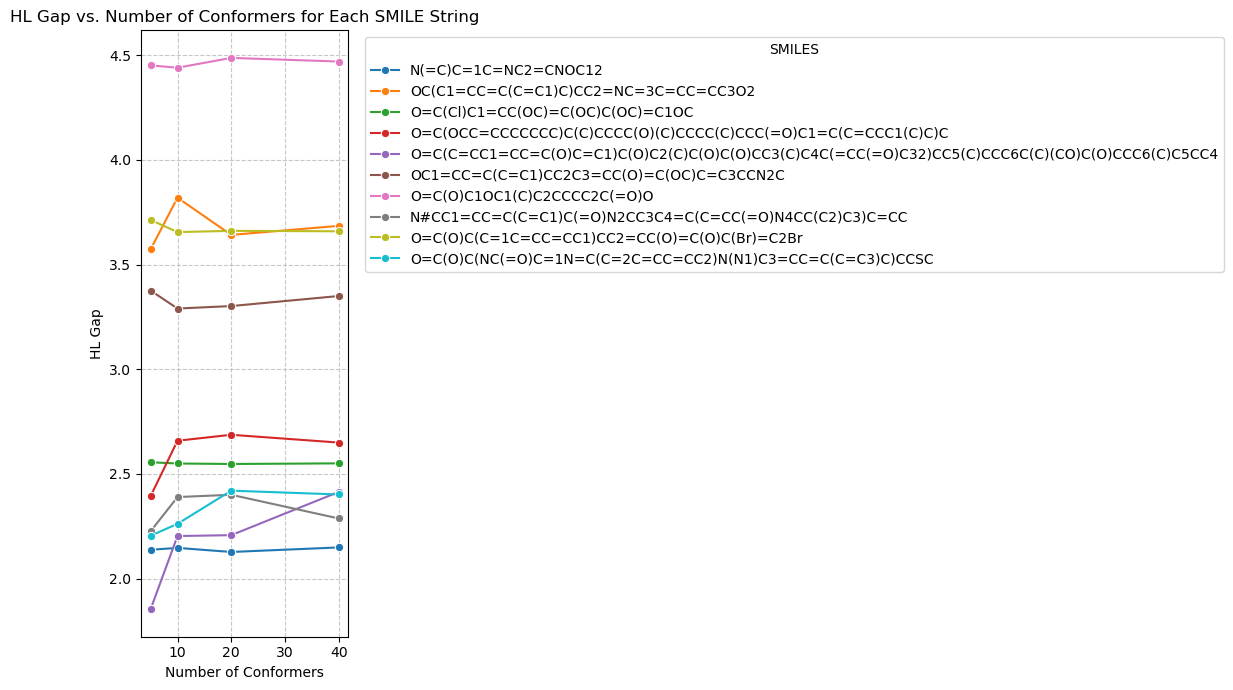

In [24]:
plt.figure(figsize=(12, 7)) # Adjust figure size as needed
sns.lineplot(data=loaded_df_pickle, x='num_conformers', y='hl_gap', hue='smiles', marker='o')

plt.title('HL Gap vs. Number of Conformers for Each SMILE String')
plt.xlabel('Number of Conformers')
plt.ylabel('HL Gap')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='SMILES', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()